In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ecom_data_clean.csv')
df

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,3.0,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [4]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['preferred_login_device', 'preferred_payment_mode', 'gender',
       'prefered_order_cat', 'marital_status'],
      dtype='object')

In [5]:
ordinal_cols = ['gender']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
onehot_cols

['prefered_order_cat',
 'preferred_payment_mode',
 'marital_status',
 'preferred_login_device']

In [6]:
import sklearn.compose
import sklearn.preprocessing
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)

data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,gender,prefered_order_cat_Fashion,prefered_order_cat_Grocery,prefered_order_cat_Laptop & Accessory,prefered_order_cat_Mobile,prefered_order_cat_Mobile Phone,prefered_order_cat_Others,preferred_payment_mode_CC,preferred_payment_mode_COD,preferred_payment_mode_Cash on Delivery,...,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,3.0,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.0,151.0
5626,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,3.0,225.0
5627,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.0,186.0
5628,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.0,179.0


In [7]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 3.3 MB/s eta 0:00:00


In [8]:
data_transformed_df = (
    data_transformed_df.clean_names(
        case_type="snake"
    )
)
data_transformed_df.columns

Index(['gender', 'prefered_order_cat_fashion', 'prefered_order_cat_grocery',
       'prefered_order_cat_laptop_&_accessory', 'prefered_order_cat_mobile',
       'prefered_order_cat_mobile_phone', 'prefered_order_cat_others',
       'preferred_payment_mode_cc', 'preferred_payment_mode_cod',
       'preferred_payment_mode_cash_on_delivery',
       'preferred_payment_mode_credit_card',
       'preferred_payment_mode_debit_card', 'preferred_payment_mode_e_wallet',
       'preferred_payment_mode_upi', 'marital_status_divorced',
       'marital_status_married', 'marital_status_single',
       'preferred_login_device_computer',
       'preferred_login_device_mobile_phone', 'preferred_login_device_phone',
       'churn', 'tenure', 'city_tier', 'warehouse_to_home',
       'hour_spend_on_app', 'number_of_device_registered',
       'satisfaction_score', 'number_of_address', 'complain',
       'order_amount_hike_fromlast_year', 'coupon_used', 'order_count',
       'day_since_last_order', 'cashback

In [9]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("prefered_order_cat_", "order_").replace("preferred_payment_mode_", "payment_").replace("preferred_login_device_", "login_").replace("marital_status_", "")
)
data_transformed_df

,gender,order_fashion,order_grocery,order_laptop_&_accessory,order_mobile,order_mobile_phone,order_others,payment_cc,payment_cod,payment_cash_on_delivery,...,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,3.0,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.0,151.0
5626,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,3.0,225.0
5627,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.0,186.0
5628,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.0,179.0


In [10]:
data_transformed_df = data_transformed_df.rename(
    columns={
        "order_laptop_&_accessory":"order_laptop",
        "order_mobile":"order_phone",
        "payment_cash_on_delivery":"payment_cash",
        "payment_credit_card":"payment_credit",
        "payment_debit_card":"payment_debit",
        "payment_e_wallet":"payment_ewallet",
        "login_mobile_phone":"login_mobile",
        "warehouse_to_home":"distance",
        "hour_spend_on_app":"hour_spend",
        "number_of_device_registered":"device_registered",
        "number_of_address":"number_address",
        "order_amount_hike_fromlast_year":"order_lastyear",
        "day_since_last_order":"days_lastorder"
    }
)
data_transformed_df.columns

Index(['gender', 'order_fashion', 'order_grocery', 'order_laptop',
       'order_phone', 'order_mobile_phone', 'order_others', 'payment_cc',
       'payment_cod', 'payment_cash', 'payment_credit', 'payment_debit',
       'payment_ewallet', 'payment_upi', 'divorced', 'married', 'single',
       'login_computer', 'login_mobile', 'login_phone', 'churn', 'tenure',
       'city_tier', 'distance', 'hour_spend', 'device_registered',
       'satisfaction_score', 'number_address', 'complain', 'order_lastyear',
       'coupon_used', 'order_count', 'days_lastorder', 'cashback_amount'],
      dtype='object')

In [11]:
data_transformed_df.dtypes

,0
gender,float64
order_fashion,float64
order_grocery,float64
order_laptop,float64
order_phone,float64
order_mobile_phone,float64
order_others,float64
payment_cc,float64
payment_cod,float64
payment_cash,float64


# CORRELACIÓN

In [12]:
corr_matrix = data_transformed_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.250188
single,0.180847
order_mobile_phone,0.154387
order_phone,0.113364
device_registered,0.107939
satisfaction_score,0.105481
city_tier,0.084703
payment_cod,0.083933
login_phone,0.078916


<Axes: >

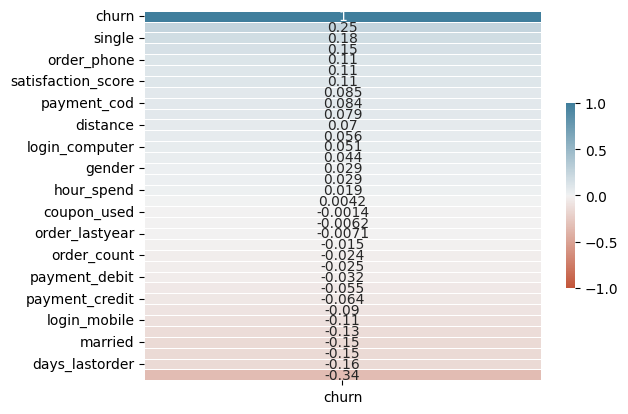

In [13]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [14]:
corr_filtered = corr_churn[corr_churn > 0]
cols = corr_filtered.index.tolist()
cols

['gender',
 'order_phone',
 'order_mobile_phone',
 'payment_cc',
 'payment_cod',
 'payment_ewallet',
 'payment_upi',
 'single',
 'login_computer',
 'login_phone',
 'churn',
 'city_tier',
 'distance',
 'hour_spend',
 'device_registered',
 'satisfaction_score',
 'number_address',
 'complain']

In [15]:
df_data = data_transformed_df[cols].copy()
df_data.head(5)

,gender,order_phone,order_mobile_phone,payment_cc,payment_cod,payment_ewallet,payment_upi,single,login_computer,login_phone,churn,city_tier,distance,hour_spend,device_registered,satisfaction_score,number_address,complain
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,6.0,3.0,3.0,2.0,9.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,8.0,3.0,4.0,3.0,7.0,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,30.0,2.0,4.0,3.0,6.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,15.0,2.0,4.0,5.0,8.0,0.0
4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,12.0,3.0,3.0,5.0,3.0,0.0


In [16]:
df_data.shape

(5630, 18)

# ESCALAMIENTO DE DATOS

In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_data)
df_scaled = pd.DataFrame(df_scaled)
df_scaled.columns = df_data.columns
df_scaled

,gender,order_phone,order_mobile_phone,payment_cc,payment_cod,payment_ewallet,payment_upi,single,login_computer,login_phone,churn,city_tier,distance,hour_spend,device_registered,satisfaction_score,number_address,complain
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.008197,0.6,0.4,0.25,0.380952,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.024590,0.6,0.6,0.50,0.285714,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.204918,0.4,0.6,0.50,0.238095,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.081967,0.4,0.6,1.00,0.333333,0.0
4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.057377,0.6,0.4,1.00,0.095238,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.204918,0.6,0.2,0.00,0.238095,0.0
5626,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.065574,0.6,0.8,1.00,0.238095,0.0
5627,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.049180,0.6,0.2,0.75,0.095238,1.0
5628,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.032787,0.8,0.8,0.75,0.142857,0.0


# ENTRENAMIENTO DE RED NEURONAL

In [35]:
from sklearn.model_selection import train_test_split
X = df_scaled.drop("churn",axis=1)
y = df_scaled['churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [36]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

red = Sequential()
entrada = Dense(units=17,activation='relu')
oculta1 = Dense(units=100,activation='relu')
oculta2 = Dense(units=100,activation='relu')
salida = Dense(1,activation='sigmoid')

red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red.compile(
    #optimizer= tf.keras.optimizers.RMSprop(learning_rate=0.01),
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [37]:
red1 = red.fit(X_train,y_train,batch_size=100,epochs=7,validation_data=(X_test, y_test))

Epoch 1/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8169 - loss: 0.5677 - val_accuracy: 0.8319 - val_loss: 0.4578
Epoch 2/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8339 - loss: 0.4586 - val_accuracy: 0.8319 - val_loss: 0.4353
Epoch 3/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8205 - loss: 0.4621 - val_accuracy: 0.8319 - val_loss: 0.4116
Epoch 4/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8360 - loss: 0.4072 - val_accuracy: 0.8324 - val_loss: 0.3873
Epoch 5/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8334 - loss: 0.4023 - val_accuracy: 0.8496 - val_loss: 0.3655
Epoch 6/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8519 - loss: 0.3763 - val_accuracy: 0.8532 - val_loss: 0.3555
Epoch 7/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8483 - loss: 0.3709 - val_accuracy: 0.8561 - val_loss: 0.3537


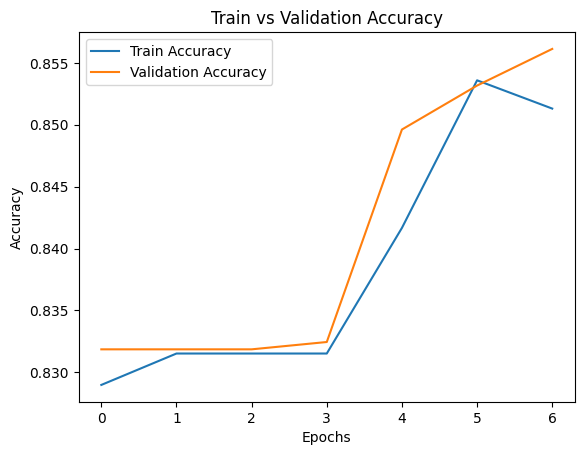

In [38]:
# Obtener los valores de accuracy y validation accuracy
train_acc = red1.history['accuracy']
val_acc = red1.history['val_accuracy']

# Crear el gráfico
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
el score de validacion y predicción es 0.8561278863232682


<Figure size 1100x1100 with 0 Axes>

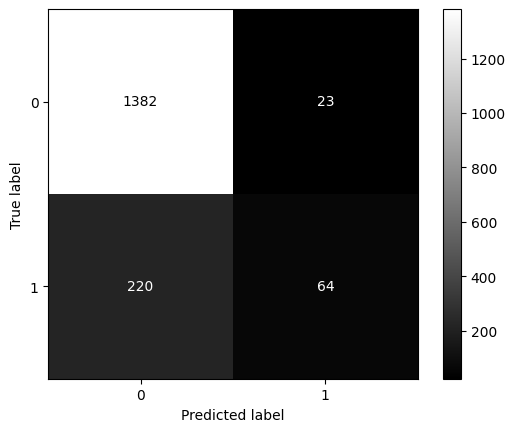

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el score de validacion y predicción es {score}')

fig = plt.figure(figsize=(11,11))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap='gray')
plt.show()

# BUSCAMOS VALORES OPTIMOS CON KERAS TUNER

In [32]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


In [42]:
import keras_tuner as kt

In [40]:
def build_model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(hp.Int("units1", min_value=8, max_value=64, step=8), activation="relu", input_shape=(X_train.shape[1],)))
  model.add(keras.layers.Dense(hp.Int("units2",min_value=8,max_value=64,step=8),activation='relu'))
  model.add(keras.layers.Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=keras.optimizers.Adam(hp.Choice("learning_rate",[0.001,0.01,0.1])),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

In [43]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=5,
    factor=3,
    directory="kt_search",
    project_name='ecom_data'
)

tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 06s]
val_accuracy: 0.8579040765762329

Best val_accuracy So Far: 0.8691533207893372
Total elapsed time: 00h 01m 00s


/usr/local/lib/python3.11/dist-packages/keras_tuner/src/engine/oracle.py:102: DeprecationWarning: currentThread() is deprecated, use current_thread() instead
  thread_name = threading.currentThread().getName()
/usr/local/lib/python3.11/dist-packages/keras_tuner/src/engine/oracle.py:102: DeprecationWarning: getName() is deprecated, get the name attribute instead
  thread_name = threading.currentThread().getName()


In [44]:
# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejor configuración: {best_hps.values}")

Mejor configuración: {'units1': 64, 'units2': 48, 'learning_rate': 0.01, 'tuner/epochs': 5, 'tuner/initial_epoch': 2, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0002'}


In [45]:
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7973 - loss: 0.4660 - val_accuracy: 0.8366 - val_loss: 0.3747
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8476 - loss: 0.3710 - val_accuracy: 0.8461 - val_loss: 0.3696
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.3512 - val_accuracy: 0.8662 - val_loss: 0.3447
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8673 - loss: 0.3311 - val_accuracy: 0.8656 - val_loss: 0.3328
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8703 - loss: 0.3235 - val_accuracy: 0.8709 - val_loss: 0.3276


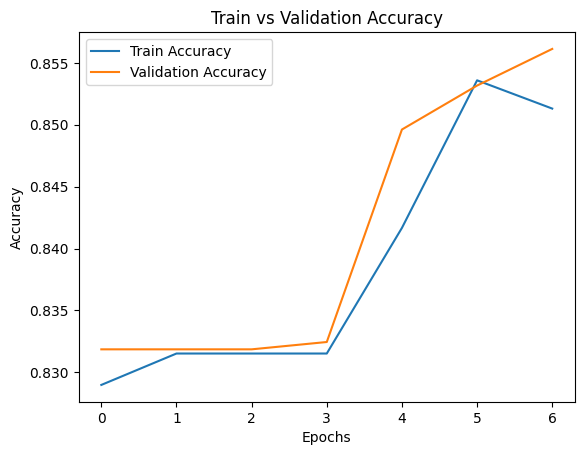

In [46]:
# Obtener los valores de accuracy y validation accuracy
train_acc = red1.history['accuracy']
val_acc = red1.history['val_accuracy']

# Crear el gráfico
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
el score de validacion y predicción es 0.8561278863232682


<Figure size 1100x1100 with 0 Axes>

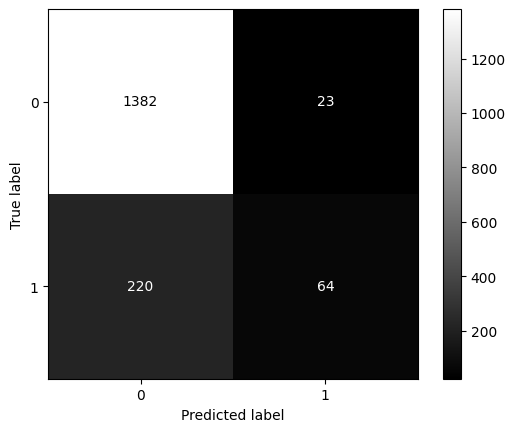

In [47]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el score de validacion y predicción es {score}')

fig = plt.figure(figsize=(11,11))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap='gray')
plt.show()